# RAINFALL PATTERN ANALYSIS OF CHENNAI(2000-2025)

## Introduction:
This project explores 25 years of daily rainfall data in Chennai to understand seasonal patterns, yearly variability, and extreme rainfall events.

In [1]:
import pandas as pd
df=pd.read_csv("chennai_rainfall_data.csv")
df.head()

,Date,Rainfall_mm_day
0,2000-01-01,0.04
1,2000-01-02,0.02
2,2000-01-03,0.01
3,2000-01-04,0.00
4,2000-01-05,0.21


# DATA DESCRIPTION

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9361 entries, 0 to 9360
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             9361 non-null   object 
 1   Rainfall_mm_day  9361 non-null   float64
dtypes: float64(1), object(1)
memory usage: 146.4+ KB


,Rainfall_mm_day
count,9361.000000
mean,3.518195
std,9.261674
min,0.000000
25%,0.000000
50%,0.290000
75%,2.850000
max,187.880000


In [4]:
df.isnull().sum()

Date               0
Rainfall_mm_day    0
dtype: int64


The dataset contains daily rainfall records from 2000 to 2025 with the following columns:
Date
Rainfall_mm_day
Total rows: 9361
No missing values

In [5]:
df=df.dropna()

# DATA CLEANING AND PREPROCESSING

In [8]:
df["Date"]=pd.to_datetime(df["Date"])
df["Year"]=df["Date"].dt.year
df["Month"]=df["Date"].dt.month


The Date column was converted into datetime format to enable time-based analysis. Year and Month features were extracted for aggregation and seasonal analysis.

In [13]:
df['Rainfall_mm_day'].describe()

count    9361.000000
mean        3.518195
std         9.261674
min         0.000000
25%         0.000000
50%         0.290000
75%         2.850000
max       187.880000
Name: Rainfall_mm_day, dtype: float64

# EXPLORATORY DATA ANALYSIS

## Year-wise Rainfall Trend

In [14]:
yearly = df.groupby('Year')['Rainfall_mm_day'].sum()
yearly.sort_values(ascending=False).head()

Year
2015    1961.46
2005    1894.66
2021    1841.35
2024    1623.87
2020    1560.54
Name: Rainfall_mm_day, dtype: float64


Rainfall varies significantly across years, with peak rainfall observed in 2015. No strong long-term increasing trend is observed.

<Axes: xlabel='Year'>

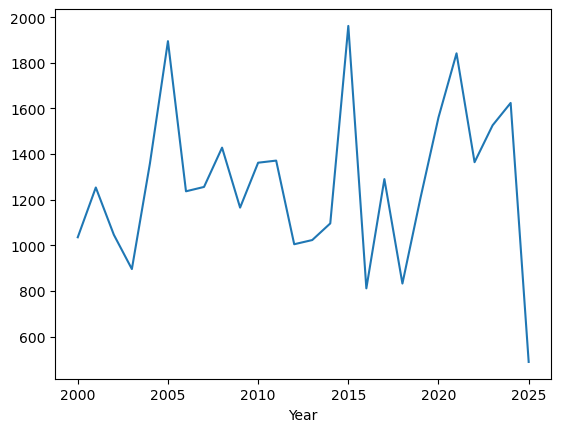

In [15]:
yearly.plot()

## Monthly Rainfall Distribution

In [29]:
monthly = df.groupby('Month')['Rainfall_mm_day'].sum()
monthly.sort_values(ascending=False)

Month
11    7805.86
10    6237.64
9     3559.53
8     3545.69
12    3452.53
7     3004.21
6     2039.57
5     1458.86
4      616.45
1      592.45
3      369.05
2      251.98
Name: Rainfall_mm_day, dtype: float64


Rainfall is highly concentrated during October and November, indicating strong Northeast Monsoon influence.

<Axes: xlabel='Month'>

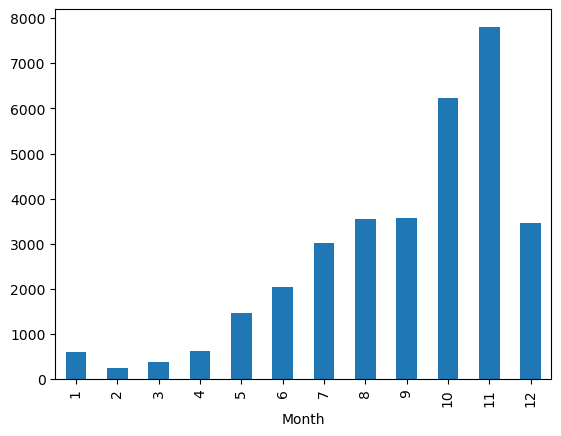

In [30]:
monthly.plot(kind='bar')

In [18]:
def season(month):
    if month in [10,11,12]:
        return "Northeast Monsoon"
    elif month in [6,7,8,9]:
        return "Southwest Monsoon"
    else:
        return "Summer"

df['Season'] = df['Month'].apply(season)

df.groupby('Season')['Rainfall_mm_day'].mean()

Season
Northeast Monsoon    7.606970
Southwest Monsoon    3.883951
Summer               0.836204
Name: Rainfall_mm_day, dtype: float64

In [19]:
df.sort_values(by='Rainfall_mm_day', ascending=False).head(5)

,Date,Rainfall_mm_day,Year,Month,Season
8738,2023-12-04,187.88,2023,12,Northeast Monsoon
3253,2008-11-27,178.98,2008,11,Northeast Monsoon
2126,2005-10-27,168.33,2005,10,Northeast Monsoon
5813,2015-12-01,132.57,2015,12,Northeast Monsoon
9100,2024-11-30,128.29,2024,11,Northeast Monsoon


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df[['Year','Month']]
y = df['Rainfall_mm_day']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.07748609529119443


The Random Forest model achieved a low R² score (~0.07), indicating that Year and Month alone are insufficient predictors of daily rainfall. Rainfall depends on complex atmospheric factors not included in this dataset.

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

## Daily Rainfall Distribution (Histogram)

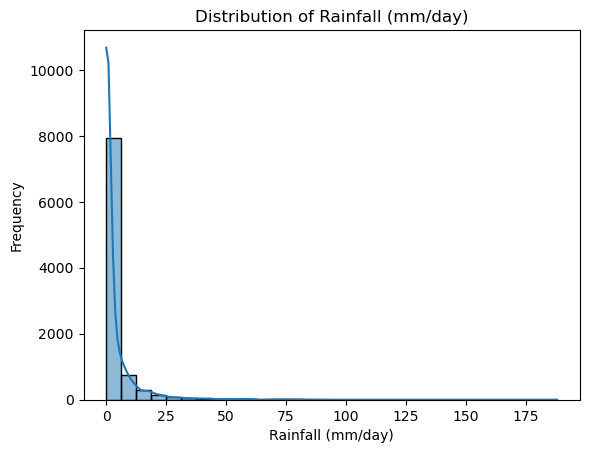

In [22]:
sns.histplot(df['Rainfall_mm_day'], bins=30, kde=True)
plt.title('Distribution of Rainfall (mm/day)')
plt.xlabel('Rainfall (mm/day)')
plt.ylabel('Frequency')
plt.show()


The distribution is positively skewed, with many dry days and few extreme rainfall events.

## Monthly Boxplot Analysis

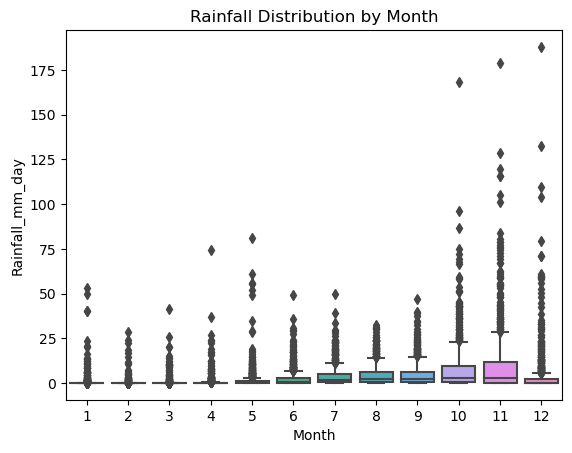

In [23]:
sns.boxplot(x='Month', y='Rainfall_mm_day', data=df)
plt.title('Rainfall Distribution by Month')
plt.show()


 Monsoon months show higher variability and more extreme outliers compared to other months.

## Yearly scatterplot Analysis

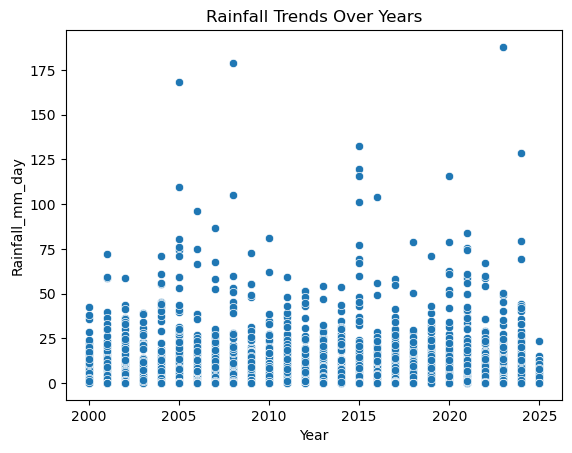

In [24]:
sns.scatterplot(x='Year', y='Rainfall_mm_day', data=df)
plt.title('Rainfall Trends Over Years')
plt.show()


- Rainfall levels are significantly higher in certain months.
- November appears to have the highest concentration of high rainfall values.
- Summer months show comparatively lower rainfall.

## Correlation Heatmap

In [28]:
df[['Year','Month','Rainfall_mm_day']].corr()

,Year,Month,Rainfall_mm_day
Year,1.000000,-0.026905,0.017492
Month,-0.026905,1.000000,0.275818
Rainfall_mm_day,0.017492,0.275818,1.000000



 Weak correlation between Year and rainfall indicates no strong long-term trend. Month shows seasonal influence.

## Extreme Rainfall Events

In [26]:
df['Heavy_Rain'] = df['Rainfall_mm_day'] > 100
df['Heavy_Rain'].sum()

12


Extreme rainfall events (>100 mm/day) are predominantly observed during the Northeast Monsoon season.

In [27]:
print("Average Rainfall on Heavy Rain Days:", df[df['Heavy_Rain']]['Rainfall_mm_day'].mean())

Average Rainfall on Heavy Rain Days: 130.52833333333334


# Key Findings

Rainfall in Chennai is highly seasonal.

November records the highest average rainfall.

Significant inter-annual variability exists.

Extreme rainfall events contribute heavily to yearly totals.

No strong long-term increasing rainfall trend observed.

# Conclusion

This analysis highlights the seasonal nature of Chennai’s rainfall and the impact of extreme monsoon events. The findings can be useful for urban planning and flood preparedness strategies.